# 23. MK1 v3: 하나의 순환, 그리고 스스로 자라기

MK1 v2는 시험 네 개에 **배선 네 개**였어. 어떤 위성을 쓸지, 언제 거절할지를 내가 시험을 보고 정했지. v3는 이걸 **하나의 순환**으로 바꾼 거야: 칠판 하나, 결정 규칙 하나(보정한 P(맞음)으로 기대 점수 계산), 피드백 통로 하나.

여기서 보는 것:
1. 왜 v3인가 (손 배선 네 개 vs 순환 하나)
2. **보정기**: 위성 신호를 모아 "이 답이 맞을 확률"을 내는 작은 로지스틱 머리, 그리고 시험 개발용으로 옮겨 가는지
3. 남은 몫 재기: 결정을 더 잘하기 vs 구해 내기
4. 섞인 개발용 흐름: 시험 종류를 안 알려 줘도 시험별 성적이 그대로인지
5. 섞인 봉인 시험 (MuSiQue + 과제 흐름 2,400개) vs E4B / E2B
6–7. **스스로 자라기**: 과제 이름 없이 맥락을 알아채고 **자라는 부품**을 새로 만드는지
8. 지금까지의 외부 시험 점수판

설계와 판정 규칙: `design/processing-flow-v3-2026-10-10.md` (1–12절), 왜 바꿨는지: `design/flow-analysis-2026-10-10.md`. 여기선 저장된 결과 파일만 읽어서 그려 (모델 안 돌림).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch
from cognitive_lab import summary_v3 as S
from cognitive_lab import viz as V
V.setup()
SYS_COLOR = {"v3": V.AQUA, "mk1": V.AQUA, "e4b": V.ORANGE, "e2b": V.NEUTRAL}
cal, ex, mixed, mixed_on = S.calibrator(), S.exam_dev(), S.mixed_dev(), S.mixed_dev_cache_on()
sealed, gv = S.sealed(), {p: S.growth_verdict(p) for p in ("dev", "sealed")}
print("보정기 (보정 데이터 1,000문제, 5겹 CV): P(맞음) AUROC", cal["right"]["auroc_cv"], "ECE", cal["right"]["ece_cv"],
      "| P(답할 수 있음) AUROC", cal["answerable"]["auroc_cv"], "ECE", cal["answerable"]["ece_cv"])
for k in ("rgb", "musique"):
    e = ex[k]
    print(f"시험 개발용 {k:8s} P(맞음) AUROC {e['right']['auroc']:.3f} | 말하기 혼자 {e['net_speaker_alone']:.3f}"
          f" | v3 {e['net_v3_calibrated']:.3f} | v2 손 배선 {e['net_v2_hand_wired']:.3f}")
print("봉인 섞인 시험:", {g: sealed["score"][g] for g in sealed["score"]})
print("자라기 봉인 정확도:", gv["sealed"]["accuracy"], "| 부품 수:", gv["sealed"]["parts"])

보정기 (보정 데이터 1,000문제, 5겹 CV): P(맞음) AUROC 0.773 ECE 0.053 | P(답할 수 있음) AUROC 0.882 ECE 0.046
시험 개발용 rgb      P(맞음) AUROC 0.893 | 말하기 혼자 0.692 | v3 0.800 | v2 손 배선 0.823
시험 개발용 musique  P(맞음) AUROC 0.759 | 말하기 혼자 0.500 | v3 0.580 | v2 손 배선 0.560
봉인 섞인 시험: {'musique': {'v3': 0.5875, 'e4b': 0.5825, 'e2b': 0.595}, 'taskstream named': {'v3': 0.75, 'e4b': 0.796, 'e2b': 0.675}, 'taskstream symbolic': {'v3': 0.725, 'e4b': 0.662, 'e2b': 0.468}}
자라기 봉인 정확도: {'mk1': 0.5563, 'mk1-fixed': 0.4462, 'e2b': 0.45, 'e4b': 0.5988, 'growth': 0.5625, 'one': 0.4587, 'oracle': 0.7275} | 부품 수: {'mk1': 5, 'mk1-fixed': 1, 'growth': 5}


## 1. 왜 v3: 배선 네 개 → 순환 하나

v2는 모양이 다 비슷했어(말하기 위성이 기본 답 → 다른 위성이 신호 → 결정 규칙). 그런데 결정 규칙이 시험마다 달랐고(손 문턱, 세는 중재자, 고정 순서), 위성끼리 정보도 안 오가고, 말하기 위성을 늘 불렀어. 피드백으로 배우는 곳도 과제 흐름 하나뿐이었고.

v3에선 손 배선 네 개가 이 순환의 특수한 경우가 돼. 정직한 메모: 입력 종류 고르기(형태 보기)는 **고정 규칙**이야. 하나로 통일된 건 칠판, 결정 규칙, 피드백 통로, 비용 기록이야.

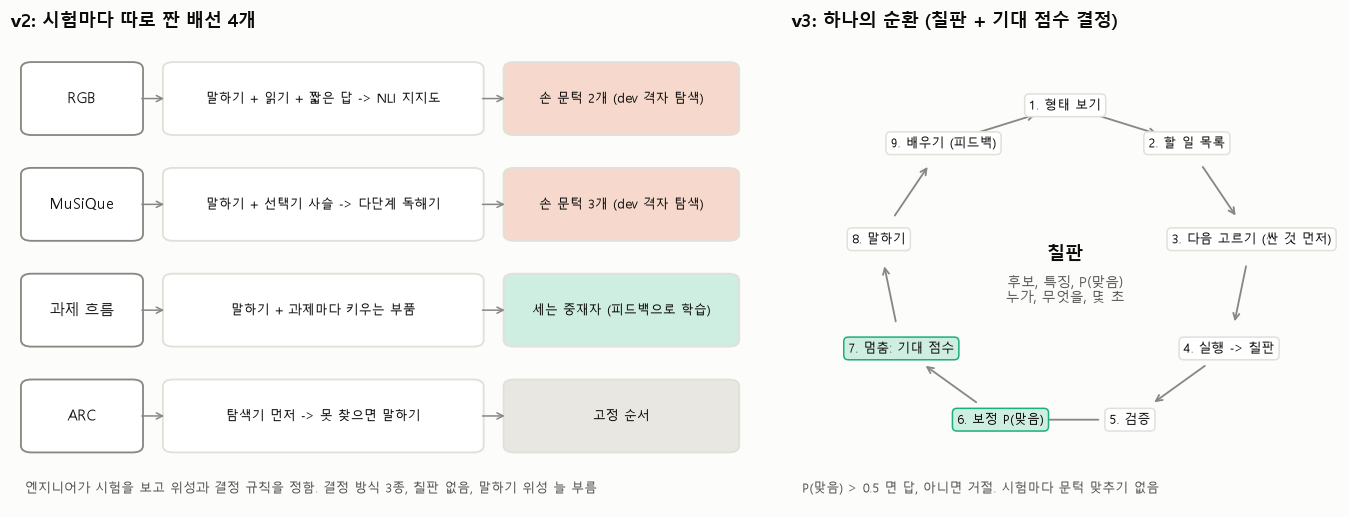

In [2]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={"width_ratios": [1.35, 1]})
for a in (ax, bx):
    a.set_xlim(-0.02, 1.02); a.set_ylim(-0.03, 1); a.axis("off")

def box(a, x, y, w, h, text, fc, ec, size=9, color=V.TEXT):
    a.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.006,rounding_size=0.015", fc=fc, ec=ec, lw=1.2))
    a.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=size, color=color)

ax.set_title("v2: 시험마다 따로 짠 배선 4개", pad=10)
dec_color = ["#f6d9cc", "#f6d9cc", "#cfeee2", "#e8e7e1"]
for i, (exam, flow, decide) in enumerate(S.FLOWS_V2):
    y = 0.80 - i * 0.235
    box(ax, 0.00, y, 0.16, 0.15, exam, "#ffffff", V.MUTED, 10)
    box(ax, 0.20, y, 0.44, 0.15, flow, "#ffffff", V.GRID, 8.5)
    box(ax, 0.68, y, 0.32, 0.15, decide, dec_color[i], V.GRID, 8.5)
    for x0, x1 in ((0.16, 0.20), (0.64, 0.68)):
        ax.annotate("", xy=(x1, y + 0.075), xytext=(x0, y + 0.075), arrowprops=dict(arrowstyle="->", color=V.MUTED))
ax.text(0.0, 0.0, "엔지니어가 시험을 보고 위성과 결정 규칙을 정함. 결정 방식 3종, 칠판 없음, 말하기 위성 늘 부름",
        fontsize=8.5, color=V.TEXT_SECONDARY)

bx.set_title("v3: 하나의 순환 (칠판 + 기대 점수 결정)", pad=10)
n = len(S.LOOP_V3); cx, cy, r = 0.5, 0.50, 0.36
pts = [(cx + r * np.sin(2 * np.pi * k / n), cy + r * np.cos(2 * np.pi * k / n)) for k in range(n)]
for k in range(n):
    x0, y0 = pts[k]; x1, y1 = pts[(k + 1) % n]
    bx.annotate("", xy=(x0 + 0.78 * (x1 - x0), y0 + 0.78 * (y1 - y0)), xytext=(x0 + 0.22 * (x1 - x0), y0 + 0.22 * (y1 - y0)),
                arrowprops=dict(arrowstyle="->", color=V.MUTED, lw=1.2))
for k, (x, y) in enumerate(pts):
    hl = S.LOOP_V3[k].startswith(("보정", "멈춤"))
    bx.text(x, y, f"{k + 1}. {S.LOOP_V3[k]}", ha="center", va="center", fontsize=8.5,
            color=V.TEXT, bbox=dict(boxstyle="round,pad=0.35", fc="#cfeee2" if hl else "#ffffff", ec=V.AQUA if hl else V.GRID))
bx.text(cx, cy + 0.03, "칠판", ha="center", va="center", fontsize=12, fontweight="bold", color=V.TEXT)
bx.text(cx, cy - 0.05, "후보, 특징, P(맞음)\n누가, 무엇을, 몇 초", ha="center", va="center", fontsize=9, color=V.TEXT_SECONDARY)
bx.text(0.0, 0.0, "P(맞음) > 0.5 면 답, 아니면 거절. 시험마다 문턱 맞추기 없음", fontsize=8.5, color=V.TEXT_SECONDARY)
fig.tight_layout(); plt.show()

## 2. 보정기: 신호 하나씩은 약하지만 합치면

조사에서 나온 결론: 작은 모델의 자기 확신은 못 믿어. 그래서 **바깥 특징으로 배운 보정기**(작은 로지스틱 머리 두 개)를 만들었어.
- **P(맞음 | 답함)**: 말하기 위성(E2B)이 낸 이 답이 맞을 확률
- **P(답할 수 있음)**: 문서에 근거가 있을 확률
- 결정: `2·P(맞음) − 1 > 1 − P(답할 수 있음)`이면 답, 아니면 거절. **문턱 튜닝 없음**.

보정 데이터는 시험이 아닌 SQuAD 2.0 dev 300 + HotpotQA validation 300 + MuSiQue **train** 400 = 1,000문제(위성이 학습 안 한 데이터). 아래는 캐시를 끄고 다시 기록한 뒤의 수치야.

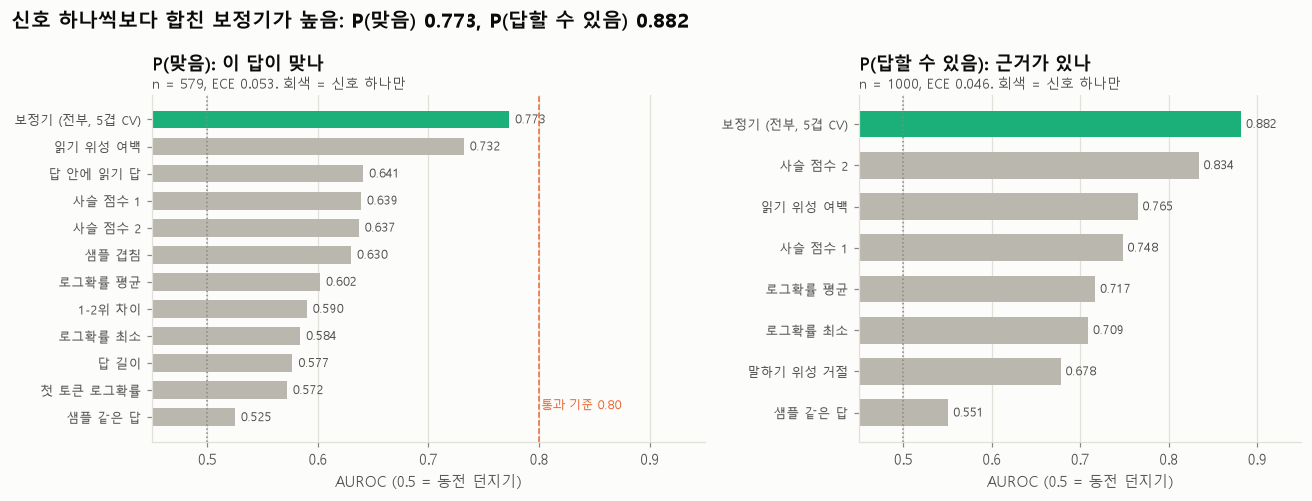

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
for ax, key, title in [(axes[0], "right", "P(맞음): 이 답이 맞나"), (axes[1], "answerable", "P(답할 수 있음): 근거가 있나")]:
    d = cal[key]
    single = sorted(d["single"].items(), key=lambda kv: kv[1])
    names = [S.SIGNAL_NAMES.get(k, k) for k, _ in single] + ["보정기 (전부, 5겹 CV)"]
    vals = [v for _, v in single] + [d["auroc_cv"]]
    colors = [V.NEUTRAL] * len(single) + [V.AQUA]
    ax.barh(range(len(vals)), vals, color=colors, height=0.65)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    ax.axvline(0.5, color=V.MUTED, lw=1, ls=":")
    ax.set_yticks(range(len(vals)), names, fontsize=8.5); ax.set_xlim(0.45, 0.95); ax.grid(axis="y", visible=False)
    ax.set_xlabel("AUROC (0.5 = 동전 던지기)")
    ax.set_title(title, pad=16)
    V.note(ax, f"n = {d['n']}, ECE {d['ece_cv']:.3f}. 회색 = 신호 하나만")
axes[0].axvline(0.80, color=V.ORANGE, lw=1, ls="--")
axes[0].text(0.802, 0.3, "통과 기준 0.80", color=V.ORANGE, fontsize=8)
fig.suptitle("신호 하나씩보다 합친 보정기가 높음: P(맞음) 0.773, P(답할 수 있음) 0.882", x=0.01, ha="left",
             fontsize=13, fontweight="bold", color=V.TEXT)
fig.tight_layout(); plt.show()

P(맞음)은 처음 정한 통과 기준(0.80)에 못 미쳐. 로그확률과 샘플 일치는 기대보다 약했어(각각 0.6 근처, 0.53–0.66). 그래도 샘플 일치는 **빼면 시험으로 옮겨 가는 게 나빠져서** 남겼어(9절: 샘플 빼면 RGB 개발용 0.808 → 0.746).

### 시험 개발용으로 옮기기 (시험 데이터로는 아무것도 안 배움)

v2 손 배선 숫자(RGB 0.823, MuSiQue 0.560)는 문서 7절 값이야. v2 문턱은 **바로 이 개발용에서 맞춘 것**이라 낙관적이야. AUROC는 캐시 끈 재기록 파일(`mk1v3-exam-dev-check.json`) 값이고, 문서 7절 표(0.901 / 0.672)는 캐시 켠 첫 기록이야.

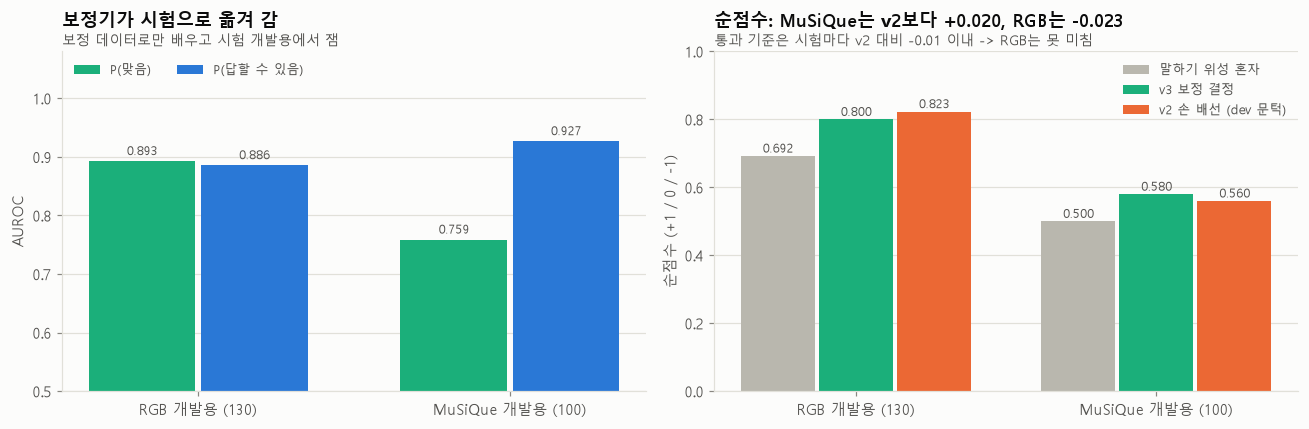

In [4]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4.0))
exams = [("rgb", "RGB 개발용 (130)"), ("musique", "MuSiQue 개발용 (100)")]
x = np.arange(2); w = 0.36
for j, (key, name, c) in enumerate([("right", "P(맞음)", V.AQUA), ("answerable", "P(답할 수 있음)", V.BLUE)]):
    vals = [ex[k][key]["auroc"] for k, _ in exams]
    ax.bar(x + (j - 0.5) * w, vals, width=w * 0.95, color=c, label=name)
    for xi, v in zip(x, vals):
        ax.text(xi + (j - 0.5) * w, v + 0.01, f"{v:.3f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [n for _, n in exams]); ax.set_ylim(0.5, 1.08); ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, loc="upper left", ncol=2); ax.set_ylabel("AUROC")
ax.set_title("보정기가 시험으로 옮겨 감", pad=16)
V.note(ax, "보정 데이터로만 배우고 시험 개발용에서 잼")
w = 0.26
for j, (key, name, c) in enumerate([("net_speaker_alone", "말하기 위성 혼자", V.NEUTRAL),
                                    ("net_v3_calibrated", "v3 보정 결정", V.AQUA),
                                    ("net_v2_hand_wired", "v2 손 배선 (dev 문턱)", V.ORANGE)]):
    vals = [ex[k][key] for k, _ in exams]
    bx.bar(x + (j - 1) * w, vals, width=w * 0.95, color=c, label=name)
    for xi, v in zip(x, vals):
        bx.text(xi + (j - 1) * w, v + 0.01, f"{v:.3f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
bx.set_xticks(x, [n for _, n in exams]); bx.set_ylim(0, 1.0); bx.grid(axis="x", visible=False)
bx.legend(fontsize=8.5, loc="upper right", ncol=1); bx.set_ylabel("순점수 (+1 / 0 / -1)")
bx.set_title("순점수: MuSiQue는 v2보다 +0.020, RGB는 -0.023", pad=16)
V.note(bx, "통과 기준은 시험마다 v2 대비 -0.01 이내 -> RGB는 못 미침")
fig.tight_layout(); plt.show()

## 3. 남은 몫 재기: "결정을 더 잘하기" vs "구해 내기"

7절에선 RGB가 낮은 이유를 "구해 내기(말하기 위성이 거절했는데 읽기 위성 근거가 강하면 그 답으로 답하기)가 없어서"라고 봤어. 만들기 전에 기록된 신호로 몫을 재 봤더니 **틀렸어**(8절).
- **결정을 더 잘하기** = 완벽한 결정(구해 내기 없음) − v3
- **구해 내기** = 읽기 위성 답을 두 번째 후보로 둘 때 더 얻는 몫

RGB 개발용에서 E2B는 답할 수 있는 질문을 한 번도 거절 안 했어. 진짜 이유는 **너무 조심하는 것**(맞는 답 거절 v3 13번, v2 6번): 보정 데이터가 시험보다 어려워서 P(맞음)을 낮게 봐(기저율 이동).

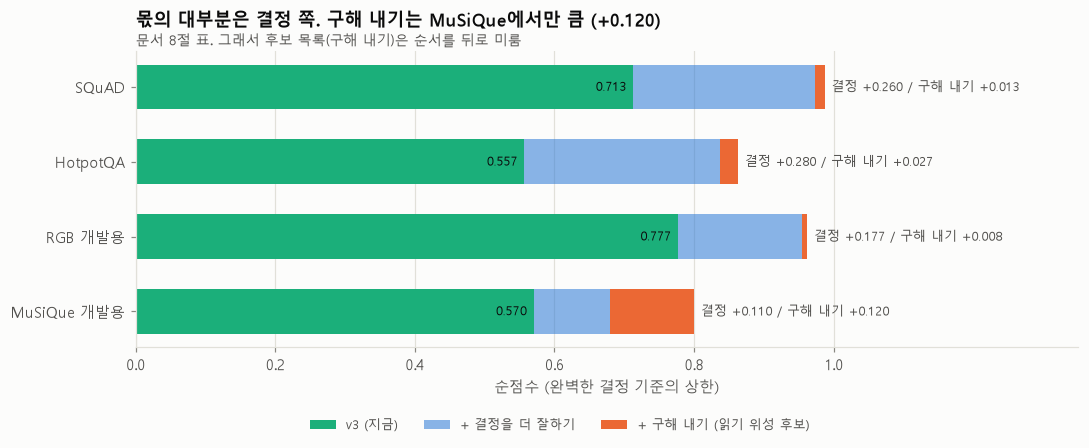

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.3))
names = [h[0] for h in S.HEADROOM]
v3 = np.array([h[1] for h in S.HEADROOM]); perf = np.array([h[2] for h in S.HEADROOM]); resc = np.array([h[3] for h in S.HEADROOM])
dec = [h[4] for h in S.HEADROOM]; res = [h[5] for h in S.HEADROOM]
y = np.arange(len(names))
ax.barh(y, v3, color=V.AQUA, height=0.6, label="v3 (지금)")
ax.barh(y, perf - v3, left=v3, color=V.BLUE, alpha=0.55, height=0.6, label="+ 결정을 더 잘하기")
ax.barh(y, resc - perf, left=perf, color=V.ORANGE, height=0.6, label="+ 구해 내기 (읽기 위성 후보)")
for i in range(len(names)):
    ax.text(v3[i] - 0.01, i, f"{v3[i]:.3f}", ha="right", va="center", fontsize=8.5, color=V.TEXT)
    ax.text(resc[i] + 0.01, i, f"결정 +{dec[i]:.3f} / 구해 내기 +{res[i]:.3f}", va="center",
            fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_yticks(y, names); ax.invert_yaxis(); ax.set_xlim(0, 1.35); ax.grid(axis="y", visible=False)
ax.set_xticks(np.arange(0, 1.01, 0.2)); ax.set_xlabel("순점수 (완벽한 결정 기준의 상한)")
ax.legend(fontsize=8.5, loc="upper center", ncol=3, bbox_to_anchor=(0.45, -0.2))
ax.set_title("몫의 대부분은 결정 쪽. 구해 내기는 MuSiQue에서만 큼 (+0.120)", pad=16)
V.note(ax, "문서 8절 표. 그래서 후보 목록(구해 내기)은 순서를 뒤로 미룸")
fig.tight_layout(); plt.show()

그래서 한 일: 보정 데이터에 MuSiQue train 400문제를 더했어(시험은 dev만 씀). RGB는 문서별 읽기 특징도 한 번 시도했는데 0.808 → 0.739로 나빠져서 되돌렸고, 더 시도하지 않고 멈췄어(새 데이터가 필요하거나 개발용에 맞추기가 되니까).

## 4. 섞인 개발용 흐름: 종류를 안 알려 줘도 성적이 그대로?

네 시험 개발용(RGB 130, MuSiQue 100, ARC 100, 과제 흐름 1,200)을 한 흐름으로 섞어서 v3 하나에 넣었어. 어느 시험인지 안 알려 줘.

**말하기 위성 건너뛰기**: 싼 신호(읽기 여백, 사슬 점수 2개)만의 P(답할 수 있음) < 0.2면 E2B를 안 부르고 거절해. 개발용 손실 0, E2B 호출 MuSiQue −40%, RGB −8.5%.

**결정성 이야기**: 첫 실행(llama.cpp 프롬프트 캐시 켬)에선 RGB만 0.769로 달랐어. 원인은 **캐시 재사용이 출력을 바꾸는 것**(같은 질문을 같은 실행에서 두 번째 부르면 20개 중 6개가 달라짐). 모든 호출에 `cache_prompt: false`를 걸고 다시 기록했어. 이전 기록은 `artifacts/results/archive/v3-cache-on/`에 있어. 아래 그림은 캐시 끈 실행이야.

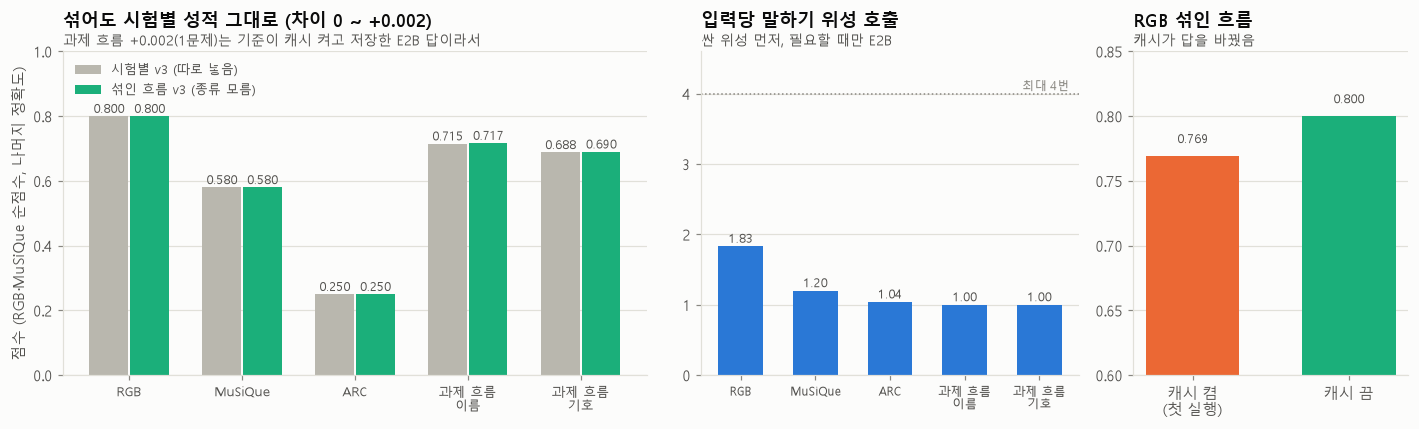

RGB          섞인 0.8000 | 시험별 0.8000 | E2B 호출/입력 1.83 | 295초
MuSiQue      섞인 0.5800 | 시험별 0.5800 | E2B 호출/입력 1.20 | 140초
ARC          섞인 0.2500 | 시험별 0.2500 | E2B 호출/입력 1.04 | 906초
과제 흐름 이름     섞인 0.7167 | 시험별 0.7150 | E2B 호출/입력 1.00 | 113초
과제 흐름 기호     섞인 0.6900 | 시험별 0.6883 | E2B 호출/입력 1.00 | 104초


In [6]:
groups = [("rgb", "RGB"), ("musique", "MuSiQue"), ("arc", "ARC"), ("taskstream|named", "과제 흐름\n이름"),
          ("taskstream|symbolic", "과제 흐름\n기호")]
fig, (ax, bx, cx) = plt.subplots(1, 3, figsize=(13, 4.0), gridspec_kw={"width_ratios": [1.7, 1.1, 0.8]})
x = np.arange(len(groups)); w = 0.36
ref = [mixed[k]["per_exam_reference"] for k, _ in groups]; mix = [mixed[k]["score"] for k, _ in groups]
ax.bar(x - w / 2, ref, width=w * 0.95, color=V.NEUTRAL, label="시험별 v3 (따로 넣음)")
ax.bar(x + w / 2, mix, width=w * 0.95, color=V.AQUA, label="섞인 흐름 v3 (종류 모름)")
for xi, a, b in zip(x, ref, mix):
    ax.text(xi - w / 2, a + 0.01, f"{a:.3f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
    ax.text(xi + w / 2, b + 0.01, f"{b:.3f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [n for _, n in groups], fontsize=8.5); ax.set_ylim(0, 1.0); ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, loc="upper left"); ax.set_ylabel("점수 (RGB·MuSiQue 순점수, 나머지 정확도)")
ax.set_title("섞어도 시험별 성적 그대로 (차이 0 ~ +0.002)", pad=16)
V.note(ax, "과제 흐름 +0.002(1문제)는 기준이 캐시 켜고 저장한 E2B 답이라서")
calls = [mixed[k]["speaker_calls_per_input"] for k, _ in groups]
bx.bar(x, calls, color=V.BLUE, width=0.6)
for xi, c in zip(x, calls):
    bx.text(xi, c + 0.05, f"{c:.2f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
bx.axhline(4, color=V.MUTED, lw=1, ls=":"); bx.text(4.4, 4.05, "최대 4번", ha="right", fontsize=8, color=V.MUTED)
bx.set_xticks(x, [n for _, n in groups], fontsize=8); bx.set_ylim(0, 4.6); bx.grid(axis="x", visible=False)
bx.set_title("입력당 말하기 위성 호출", pad=16)
V.note(bx, "싼 위성 먼저, 필요할 때만 E2B")
vals = [mixed_on["rgb"]["score"], mixed["rgb"]["score"]]
cx.bar([0, 1], vals, color=[V.ORANGE, V.AQUA], width=0.6)
for i, v in enumerate(vals):
    cx.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
cx.set_xticks([0, 1], ["캐시 켬\n(첫 실행)", "캐시 끔"]); cx.set_ylim(0.6, 0.85); cx.grid(axis="x", visible=False)
cx.set_title("RGB 섞인 흐름", pad=16)
V.note(cx, "캐시가 답을 바꿨음")
fig.tight_layout(); plt.show()
for k, n in groups:
    m = mixed[k]
    print(f"{n.replace(chr(10), ' '):12s} 섞인 {m['score']:.4f} | 시험별 {m['per_exam_reference']:.4f} | E2B 호출/입력 {m['speaker_calls_per_input']:.2f} | {m['seconds']:.0f}초")

**3단계 통과**: 얼린 v3 하나가 네 시험을 섞어 받아도 시험별 성적을 그대로 내. v2 손 배선 대비로는 MuSiQue +0.020, RGB −0.023(기준 −0.01에 못 미침, 기록한 그대로 둠).

(메모: `mk1v3-mixed-dev.json` 파일 안의 RGB·MuSiQue `per_exam_reference`는 캐시 켠 값(0.808 / 0.590)으로 남아 있어. 그림은 문서 10절대로 캐시 끈 시험별 v3(0.800 / 0.580)와 비교했어.)

## 5. 섞인 봉인 시험: v3 하나 vs E4B 혼자 vs E2B 혼자

한 번도 안 쓴 데이터만 2,400개: MuSiQue 400문제(순점수) + 과제 흐름 TREC 뺀 5과제 × 이름·기호 라벨 2,000개(피드백 받으며 온라인 정확도). 둘을 섞어서 넣고 어느 쪽인지 안 알려 줘. RGB와 ARC는 이미 다 써서 못 넣었어(격자 종류 없음).
- **주 가설**: 기호 라벨에서 v3 − E4B > 0 (구간 하한 > 0)
- **부 가설**: 세 묶음 모두 v3 − E2B > 0 (엮기가 자기 말하기 위성에 값을 더한다)

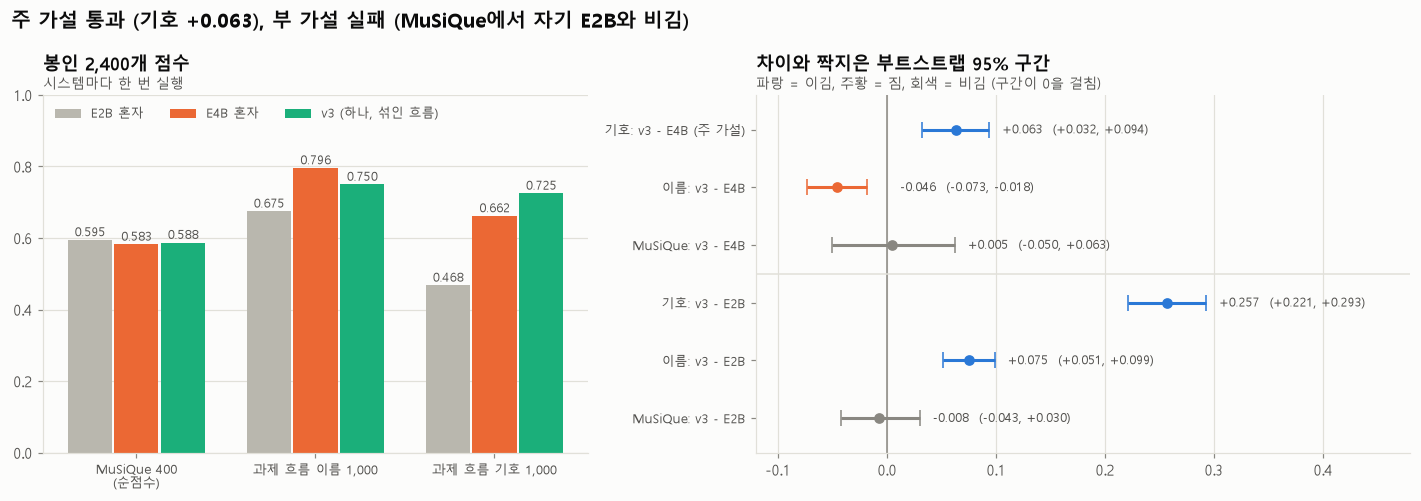

효율: MuSiQue 문제당 E2B 호출 1.375 (기록 다시 셈) | 파일: 1.375 | 말하기 위성 안 부르고 거절 31.2%
문제당 E2B 호출 분포: {0: 125, 2: 275}


In [7]:
gnames = [("musique", "MuSiQue 400\n(순점수)"), ("taskstream named", "과제 흐름 이름 1,000"), ("taskstream symbolic", "과제 흐름 기호 1,000")]
systems = [("e2b", "E2B 혼자"), ("e4b", "E4B 혼자"), ("v3", "v3 (하나, 섞인 흐름)")]
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.2]})
x = np.arange(3); w = 0.26
for j, (s, name) in enumerate(systems):
    vals = [sealed["score"][g][s] for g, _ in gnames]
    ax.bar(x + (j - 1) * w, vals, width=w * 0.95, color=SYS_COLOR[s], label=name)
    for xi, v in zip(x, vals):
        ax.text(xi + (j - 1) * w, v + 0.01, f"{v:.3f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [n for _, n in gnames], fontsize=8.5); ax.set_ylim(0, 1.0); ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, loc="upper left", ncol=3)
ax.set_title("봉인 2,400개 점수", pad=16)
V.note(ax, "시스템마다 한 번 실행")
pairs = [("taskstream symbolic: v3 - e4b", "기호: v3 - E4B (주 가설)"), ("taskstream named: v3 - e4b", "이름: v3 - E4B"),
         ("musique: v3 - e4b", "MuSiQue: v3 - E4B"), ("taskstream symbolic: v3 - e2b", "기호: v3 - E2B"),
         ("taskstream named: v3 - e2b", "이름: v3 - E2B"), ("musique: v3 - e2b", "MuSiQue: v3 - E2B")]
for i, (k, name) in enumerate(pairs):
    d, (lo, hi) = sealed["versus"][k]["difference"], sealed["versus"][k]["ci95"]
    c = V.BLUE if lo > 0 else (V.ORANGE if hi < 0 else V.MUTED)
    bx.errorbar(d, i, xerr=[[d - lo], [hi - d]], fmt="o", color=c, capsize=5, lw=2)
    bx.text(max(hi, 0) + 0.012, i, f"{S.signed(d)}  ({S.signed(lo)}, {S.signed(hi)})", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
bx.axvline(0, color=V.MUTED, lw=1); bx.axhline(2.5, color=V.GRID, lw=1)
bx.set_yticks(range(len(pairs)), [n for _, n in pairs], fontsize=8.5); bx.set_ylim(len(pairs) - 0.4, -0.6)
bx.set_xlim(-0.12, 0.48); bx.grid(axis="y", visible=False)
bx.set_title("차이와 짝지은 부트스트랩 95% 구간", pad=16)
V.note(bx, "파랑 = 이김, 주황 = 짐, 회색 = 비김 (구간이 0을 걸침)")
fig.suptitle("주 가설 통과 (기호 +0.063), 부 가설 실패 (MuSiQue에서 자기 E2B와 비김)", x=0.01, ha="left",
             fontsize=13, fontweight="bold", color=V.TEXT)
fig.tight_layout(); plt.show()
print("효율: MuSiQue 문제당 E2B 호출", round(sealed["musique_speaker_calls_mean"], 3), "(기록 다시 셈)", "| 파일:",
      sealed["v3_speaker_calls_per_musique_question"], "| 말하기 위성 안 부르고 거절", f"{sealed['musique_skipped_share']:.1%}")
print("문제당 E2B 호출 분포:", dict(sorted(sealed["musique_speaker_calls"].items())))

- **주 가설 통과**: 기호 라벨 v3 − E4B = +0.063, 구간 (+0.032, +0.094). 하나의 v3로 섞인 흐름을 받아도 "새로 배우기" 강점은 봉인 데이터에서 유지돼(이전 시험의 +0.122보다는 작음).
- **부 가설 실패**: 과제 흐름은 E2B보다 훨씬 위(이름 +0.075, 기호 +0.257)인데 **MuSiQue는 −0.008로 비김**. 개발용에서 본 보정 결정의 이득(+0.08)이 봉인에선 안 나왔어. 개발용 100문제의 운, 또는 보정 데이터 분포 차이가 후보야.
- **예상 틀림 두 개**: 이름 라벨은 비길 줄 알았는데 **짐**(−0.046). MuSiQue는 E4B에 질 줄 알았는데 **비김**(이번 짝에서 E4B가 0.583으로 낮았어).
- 효율: MuSiQue 문제당 E2B 호출 1.375번(최대 4번), 31%는 말하기 위성을 안 부르고 거절. 기록을 보면 E2B는 0번 아니면 2번(답 + 말하기)이야.
- 실행 사고: v3가 첫 MuSiQue 문제에서 멈춤(기록용 칸 `source` 누락) → 칸만 추가하고 이어 돌림. 판단은 안 바뀜.

## 6. 스스로 자라기: 과제 이름 없이 부품 키우기

다섯 과제(SUBJ, AG News, SST-2, 트윗 감정, Emotion)가 **예고 없이** 20–60개 묶음으로 바뀌고 다시 돌아와. **모든 과제가 같은 라벨 A–F**라서 지금 무슨 과제인지는 글과 피드백으로만 알 수 있어.

MK1은 맥락 추론(COIN 모델 + 변화점 감지)으로 **자라는 부품**을 써: 최근 피드백 5개를 보고 "기존 부품 / 지금 부품 / 새 맥락" 가설을 비교해서, 새 맥락이 이기면 새 부품을 키워. 전환을 감지하면 그동안 옛 부품이 잘못 배운 걸 빼서 맞는 부품으로 옮겨(되돌리기). 말하기 위성(E2B, 최근 예시 16개)과 세는 방식으로 합쳐.

봉인: 과제마다 700–860행(한 번도 안 씀), 800개, 23묶음. 주 가설은 **MK1 − MK1(자라기 끔) > 0**.

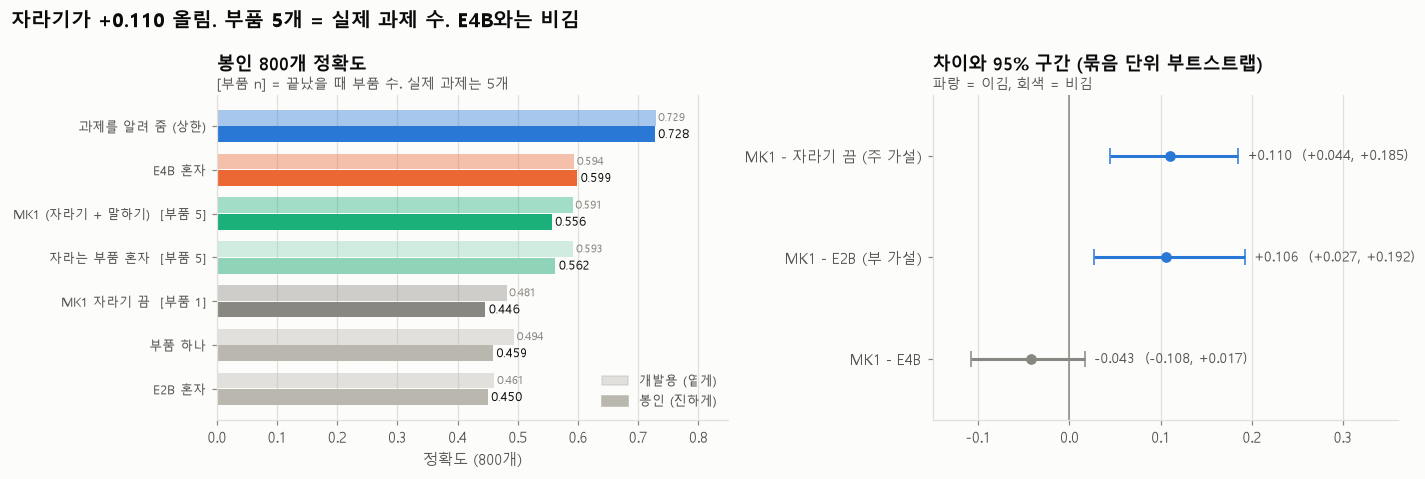

과제를 알려 줌 (상한)          봉인 0.7275 | 돌아온 과제 첫 10개 0.7588
E4B 혼자                 봉인 0.5988 | 돌아온 과제 첫 10개 0.5176
MK1 (자라기 + 말하기)        봉인 0.5563 | 돌아온 과제 첫 10개 0.5353
자라는 부품 혼자              봉인 0.5625 | 돌아온 과제 첫 10개 0.5235
MK1 자라기 끔              봉인 0.4462 | 돌아온 과제 첫 10개 0.4294
부품 하나                  봉인 0.4587 | 돌아온 과제 첫 10개 0.4824
E2B 혼자                 봉인 0.4500 | 돌아온 과제 첫 10개 0.4118


In [8]:
gl = dict(S.GROWTH_SYSTEMS)
GCOLOR = {"oracle": V.BLUE, "e4b": V.ORANGE, "mk1": V.AQUA, "growth": "#8fd3b9", "mk1-fixed": V.MUTED, "one": V.NEUTRAL, "e2b": V.NEUTRAL}
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.1, 1]})
keys = [k for k, _ in S.GROWTH_SYSTEMS]
y = np.arange(len(keys)); h = 0.38
for j, (p, name, alpha) in enumerate([("dev", "개발용", 0.4), ("sealed", "봉인", 1.0)]):
    vals = [gv[p]["accuracy"][k] for k in keys]
    ax.barh(y + (j - 0.5) * h, vals, height=h * 0.95, color=[GCOLOR[k] for k in keys], alpha=alpha, label=name)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, y[i] + (j - 0.5) * h, f"{v:.3f}", va="center", fontsize=7.5 if p == "dev" else 8.5,
                color=V.MUTED if p == "dev" else V.TEXT)
ax.set_yticks(y, [gl[k] + (f"  [부품 {gv['sealed']['parts'][k]}]" if k in gv["sealed"]["parts"] else "") for k in keys], fontsize=8.5)
ax.invert_yaxis(); ax.set_xlim(0, 0.85); ax.grid(axis="y", visible=False); ax.set_xlabel("정확도 (800개)")
ax.legend(handles=[Patch(color=V.NEUTRAL, alpha=0.4, label="개발용 (옅게)"), Patch(color=V.NEUTRAL, label="봉인 (진하게)")],
          fontsize=8.5, loc="lower right")
ax.set_title("봉인 800개 정확도", pad=16)
V.note(ax, "[부품 n] = 끝났을 때 부품 수. 실제 과제는 5개")
v = gv["sealed"]
pairs = [("mk1 - mk1-fixed", "MK1 - 자라기 끔 (주 가설)"), ("mk1 - e2b", "MK1 - E2B (부 가설)"), ("mk1 - e4b", "MK1 - E4B")]
for i, (k, name) in enumerate(pairs):
    d, (lo, hi) = v["versus"][k]["difference"], v["versus"][k]["ci95"]
    c = V.BLUE if lo > 0 else (V.ORANGE if hi < 0 else V.MUTED)
    bx.errorbar(d, i, xerr=[[d - lo], [hi - d]], fmt="o", color=c, capsize=5, lw=2)
    bx.text(max(hi, 0) + 0.01, i, f"{S.signed(d)}  ({S.signed(lo)}, {S.signed(hi)})", va="center", fontsize=9, color=V.TEXT_SECONDARY)
bx.axvline(0, color=V.MUTED, lw=1)
bx.set_yticks(range(3), [n for _, n in pairs]); bx.set_ylim(2.6, -0.6); bx.set_xlim(-0.15, 0.36); bx.grid(axis="y", visible=False)
bx.set_title("차이와 95% 구간 (묶음 단위 부트스트랩)", pad=16)
V.note(bx, "파랑 = 이김, 회색 = 비김")
fig.suptitle("자라기가 +0.110 올림. 부품 5개 = 실제 과제 수. E4B와는 비김", x=0.01, ha="left", fontsize=13, fontweight="bold", color=V.TEXT)
fig.tight_layout(); plt.show()
for k in keys:
    print(f"{gl[k]:22s} 봉인 {v['accuracy'][k]:.4f} | 돌아온 과제 첫 10개 {v['returning_first10'][k]:.4f}")

- **주 가설 통과**: MK1 − 자라기 끔 = +0.110, 구간 (+0.044, +0.185). 과제 이름 없이 스스로 맥락을 알아채고 자라는 게 점수를 올려.
- **부 가설 통과**: MK1 − E2B = +0.106. E4B와는 **비김**(−0.043, 구간 (−0.108, +0.017); 점수는 E4B가 조금 높아).
- 돌아온 과제의 첫 10개는 MK1이 E4B보다 높아(0.535 vs 0.518): 옛 부품을 다시 꺼내 써.

## 7. 흐름을 따라가 보기: 언제 어떤 부품을 썼나

위: 최근 20개 정확도. 배경 띠는 실제 과제 묶음(MK1은 이걸 못 봐). 아래 띠 두 줄: 실제 과제, MK1이 그 입력에서 쓴 부품. 부품 색은 **그 부품을 가장 많이 쓴 과제의 색**으로 칠했어(부품 번호 자체는 생긴 순서).

C:\Users\plosind\AppData\Local\Temp\ipykernel_36384\3008949536.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


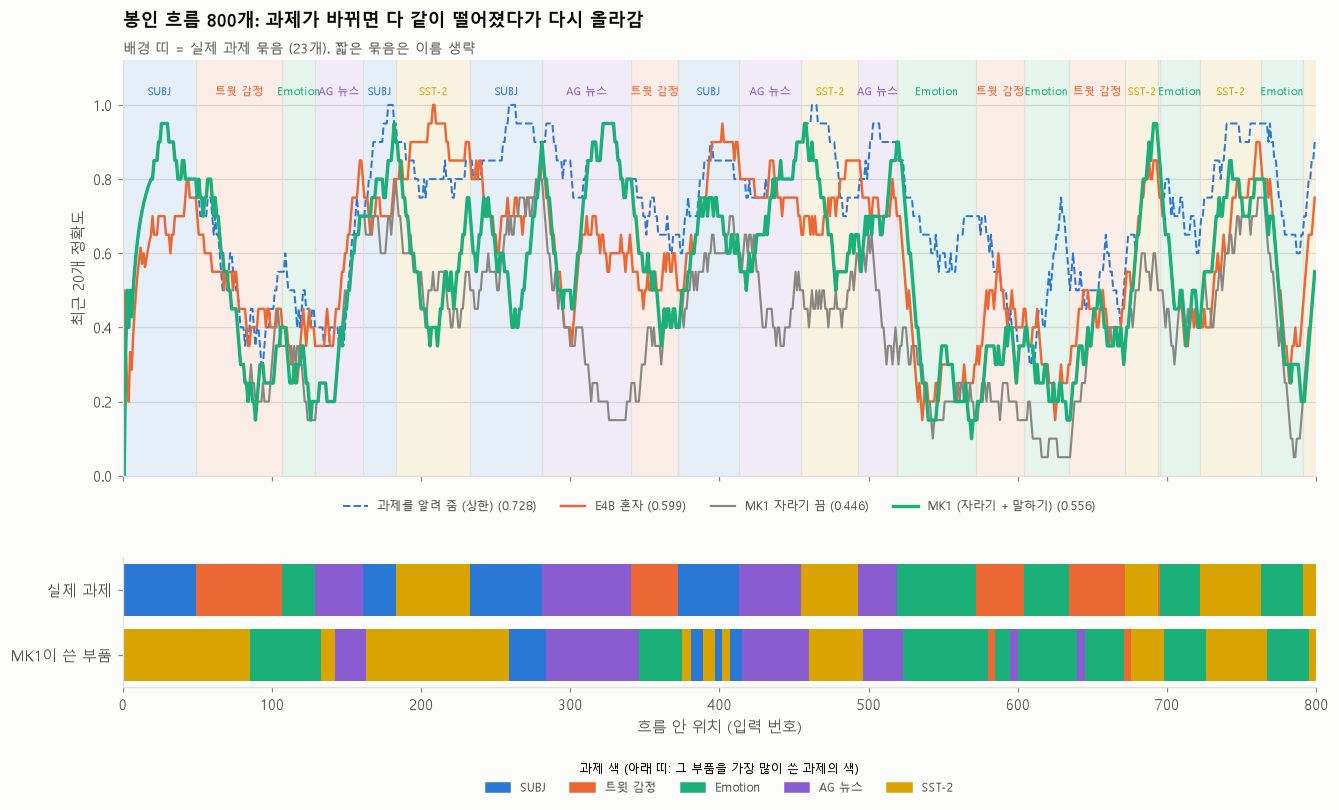

부품 -> 가장 많이 쓴 과제: {0: 'SST-2', 1: 'Emotion', 2: 'AG 뉴스', 3: 'SUBJ', 4: '트윗 감정'}


In [9]:
g = S.growth_stream("sealed")
tasks, blocks, N = g["tasks"], g["blocks"], len(g["tasks"])
TNAME = {"subj": "SUBJ", "tweet_sentiment": "트윗 감정", "emotion": "Emotion", "ag_news": "AG 뉴스", "sst2": "SST-2"}
TCOLOR = {"subj": "#2a78d6", "tweet_sentiment": "#eb6834", "emotion": "#1baf7a", "ag_news": "#8a5cd1", "sst2": "#d9a400"}
parts = g["part"]["mk1"]
tn, pids, cnt = S.part_task_counts(tasks, parts)
major = {p: tn[int(np.argmax([cnt[i][j] for i in range(len(tn))]))] for j, p in enumerate(pids)}
spans, start = [], 0
for i in range(1, N + 1):
    if i == N or blocks[i] != blocks[start]:
        spans.append((start, i, tasks[start])); start = i
fig, (ax, sx) = plt.subplots(2, 1, figsize=(14, 7.4), sharex=True, gridspec_kw={"height_ratios": [3.2, 1], "hspace": 0.3})
for a, b, t in spans:
    ax.axvspan(a, b, color=TCOLOR[t], alpha=0.10, lw=0)
    ax.axvline(a, color=V.GRID, lw=0.8)
    if b - a >= 22:
        ax.text((a + b) / 2, 1.02, TNAME[t], ha="center", va="bottom", fontsize=7.5, color=TCOLOR[t], rotation=0)
for k, lw, ls in [("oracle", 1.3, "--"), ("e4b", 1.6, "-"), ("mk1-fixed", 1.4, "-"), ("mk1", 2.2, "-")]:
    ax.plot(S.rolling(g["right"][k], 20), color=GCOLOR[k], lw=lw, ls=ls, label=f"{gl[k]} ({np.mean(g['right'][k]):.3f})")
ax.set_ylim(0, 1.12); ax.set_ylabel("최근 20개 정확도"); ax.set_xlim(0, N); ax.grid(axis="x", visible=False)
line_handles = ax.get_legend_handles_labels()
ax.set_title("봉인 흐름 800개: 과제가 바뀌면 다 같이 떨어졌다가 다시 올라감", pad=22)
V.note(ax, "배경 띠 = 실제 과제 묶음 (23개). 짧은 묶음은 이름 생략")
for i in range(N):
    sx.add_patch(plt.Rectangle((i, 1), 1, 0.8, color=TCOLOR[tasks[i]], lw=0))
    sx.add_patch(plt.Rectangle((i, 0), 1, 0.8, color=TCOLOR[major[parts[i]]], lw=0))
sx.set_ylim(-0.1, 1.9); sx.set_yticks([0.4, 1.4], ["MK1이 쓴 부품", "실제 과제"]); sx.grid(False)
sx.set_xlabel("흐름 안 위치 (입력 번호)")
handles = [Patch(color=TCOLOR[t], label=TNAME[t]) for t in tn]
sx.legend(handles=handles, fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.5), title="과제 색 (아래 띠: 그 부품을 가장 많이 쓴 과제의 색)", title_fontsize=8)
ax.legend(*line_handles, fontsize=8, loc="upper center", ncol=4, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(); plt.show()
print("부품 -> 가장 많이 쓴 과제:", {p: TNAME[t] for p, t in major.items()})

### 부품 × 과제 표 (몇 번 썼나)

부품 수는 실제 과제 수와 같은 5개야. 그런데 표를 보면 1:1로 딱 맞진 않아. 숫자로 읽어 봐: SUBJ와 SST-2가 같은 부품을 많이 같이 써(둘 다 영화 리뷰라 글 중심 코사인 0.965, 글 모양만으론 못 가름), 트윗 감정과 Emotion도 한 부품을 많이 같이 써. 문서 12절이 남은 빈칸으로 꼽은 "같은 영역 과제(SST-2/SUBJ) 구분"이 여기서 보여.

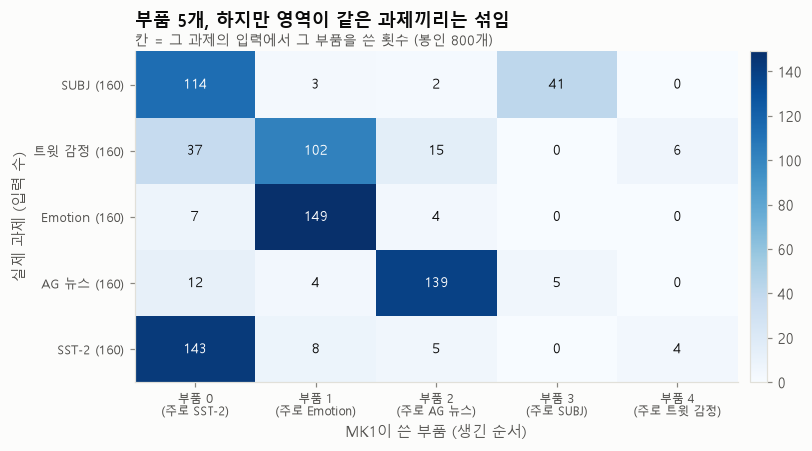

부품마다 가장 많은 과제의 몫 (순도): 0.598


In [10]:
M = np.array(cnt)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
im = ax.imshow(M, cmap="Blues", aspect="auto")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, str(M[i, j]), ha="center", va="center", fontsize=9, color="white" if M[i, j] > M.max() * 0.55 else V.TEXT)
ax.set_xticks(range(len(pids)), [f"부품 {p}\n(주로 {TNAME[major[p]]})" for p in pids], fontsize=8)
ax.set_yticks(range(len(tn)), [f"{TNAME[t]} ({sum(M[i])})" for i, t in enumerate(tn)], fontsize=8.5)
ax.grid(False); ax.set_xlabel("MK1이 쓴 부품 (생긴 순서)"); ax.set_ylabel("실제 과제 (입력 수)")
ax.set_title("부품 5개, 하지만 영역이 같은 과제끼리는 섞임", pad=16)
V.note(ax, "칸 = 그 과제의 입력에서 그 부품을 쓴 횟수 (봉인 800개)")
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.tight_layout(); plt.show()
purity = sum(M.max(axis=0)) / M.sum()
print(f"부품마다 가장 많은 과제의 몫 (순도): {purity:.3f}")

**배운 것** (문서 12절): "스스로 자라기"의 첫 외부 증거야. 누가 과제를 알려 주지 않아도 바뀜을 감지하고, 부품을 새로 만들고, 돌아온 맥락에 옛 부품을 다시 써. 이게 없으면(자라기 끔) 0.11 낮아. 4B급 LLM의 프롬프트 내 학습도 이 흐름에서 강해(최근 예시가 대부분 지금 과제라서). 이기려면 상한(과제를 알려 줌, 0.728)과의 남은 **0.17**을 줄여야 해: 감지 지연, 같은 영역 과제 구분.

## 8. 외부 시험 점수판 (지금까지, 시험마다 봉인 1회)

README의 MK1 v2 / v3 줄을 특성별로 다시 모은 거야. 비교 상대는 늘 Gemma 4 E4B 혼자.

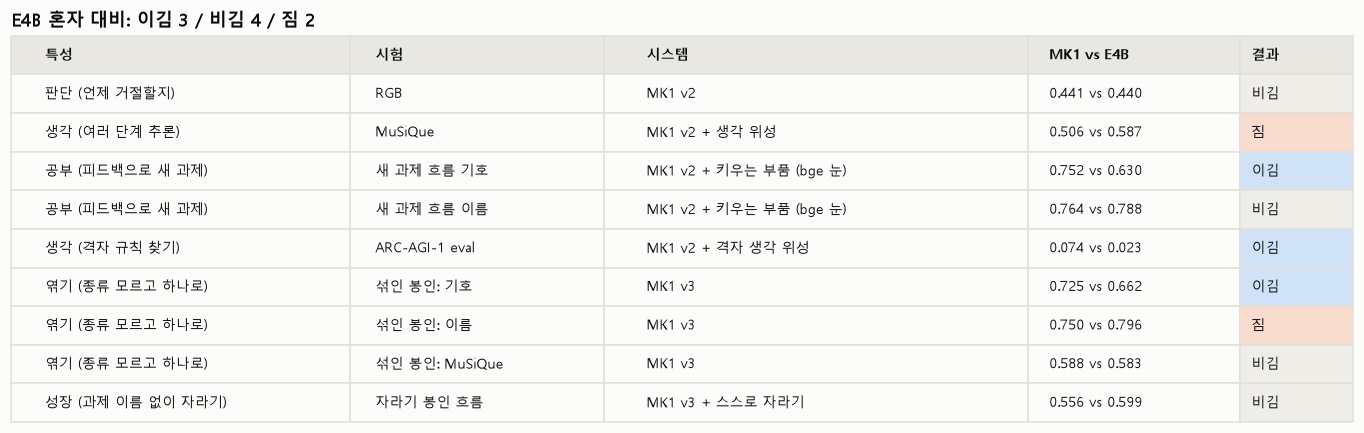

In [11]:
rows = S.SCOREBOARD
fig, ax = plt.subplots(figsize=(12.5, 0.36 * len(rows) + 0.8))
ax.axis("off")
cols = ["특성", "시험", "시스템", "MK1 vs E4B", "결과"]
tbl = ax.table(cellText=[list(r) for r in rows], colLabels=cols, bbox=[0, 0, 1, 1], cellLoc="left", colLoc="left",
               colWidths=[0.24, 0.18, 0.30, 0.15, 0.08])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
RES = {"이김": "#cfe2f7", "짐": "#fadccf", "비김": "#eeede8"}
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(V.GRID)
    if r == 0:
        cell.set_facecolor("#e8e7e1"); cell.set_text_props(fontweight="bold", color=V.TEXT)
    else:
        cell.set_facecolor(RES[rows[r - 1][4]] if c == 4 else V.SURFACE)
        cell.set_text_props(color=V.TEXT)
wins = sum(r[4] == "이김" for r in rows); ties = sum(r[4] == "비김" for r in rows); loss = sum(r[4] == "짐" for r in rows)
ax.set_title(f"E4B 혼자 대비: 이김 {wins} / 비김 {ties} / 짐 {loss}", pad=6)
fig.tight_layout(); plt.show()

## 정리

- **v3 = 하나의 순환**: 칠판, 보정 확률의 기대 점수 결정, 피드백 통로, 비용 기록을 하나로. 입력 종류 고르기는 아직 고정 규칙이야.
- **보정기**: 신호 하나씩은 약하지만(최고 읽기 위성 여백 0.73) 합치면 P(맞음) 0.773, P(답할 수 있음) 0.882. 시험 데이터로 안 배우고도 개발용에서 MuSiQue v2 +0.020, RGB v2 −0.023.
- **남은 몫은 결정 쪽**: "구해 내기가 없어서"라는 내 추측은 틀렸어. 너무 조심하는 게(기저율 이동) 진짜 이유.
- **섞어도 그대로**: 종류를 안 알려 줘도 시험별 성적 차이 0 ~ +0.002. 그 과정에서 llama.cpp 프롬프트 캐시가 출력을 바꾼다는 걸 찾아서 끄고 재현 가능하게 다시 기록했어.
- **섞인 봉인**: 기호 라벨 E4B를 이김(+0.063, 주 가설 통과). 이름 라벨 짐(−0.046), MuSiQue 비김. 자기 E2B 대비 MuSiQue 비김이라 부 가설은 실패.
- **스스로 자라기 봉인**: 자라기 끔보다 +0.110, E2B보다 +0.106, E4B와 비김. 부품 5개 = 과제 5개. 다만 같은 영역 과제끼리는 부품이 섞여서, 상한까지 0.17이 남았어.